# Tutorial 4 - DIBs other than $\lambda$6614: a width-depth scan and how to reconfigure

The method was developed for DIB $\lambda$6614, a relatively strong and broad line. To use it on
other DIBs two things must be re-examined:

1. **Is the parameter space covered?** A 50-point scan over $\sigma_{\rm DIB}=0.4-0.8\,\rm\AA$
   (step $0.1$) and $A_{\rm DIB}=0.01-0.10$ (step $0.01$) answers this, at fixed SNR and sampling.
2. **Do the priors still fit?** Every DIB has its own wavelength and its own width, so the box
   priors of `DIB` have to be set for the line at hand - that is what makes the package usable
   for other bands.

In [1]:
%matplotlib inline
import json, sys, time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

try:                                     # installed with `pip install -e .`
    import mcmc_rvsd
except ImportError:                      # or run straight from a clone
    sys.path.insert(0, str(Path.cwd().parent / 'src'))
    import mcmc_rvsd
from mcmc_rvsd import SpectralModel, StellarLine, DIB, run_mcmc, plotting
from mcmc_rvsd.io import load_result, load_mock
from mcmc_rvsd.preprocess import read_preprocessed

ROOT = Path.cwd().parent if Path.cwd().name == 'examples' else Path.cwd()
FIG = ROOT / 'docs' / 'figures'
FIG.mkdir(parents=True, exist_ok=True)
RERUN = False             # set to True to redo the MCMC yourself (minutes)
print('mcmc_rvsd', mcmc_rvsd.__version__, '|',
      'running from a repository clone' if (ROOT / 'data').is_dir() else 'running from an installed package')

mcmc_rvsd 0.1.0 | running from a repository clone


## 1. The 50-point scan

In [2]:
scan = json.loads((ROOT / 'data/mock/dib_scan_results.json').read_text())
print(f'{len(scan)} cases | sigma_DIB in '
      f'{sorted({r["sigma_true"] for r in scan})} | A_DIB in {sorted({r["A_true"] for r in scan})}')

50 cases | sigma_DIB in [0.4, 0.5, 0.6, 0.7, 0.8] | A_DIB in [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1]


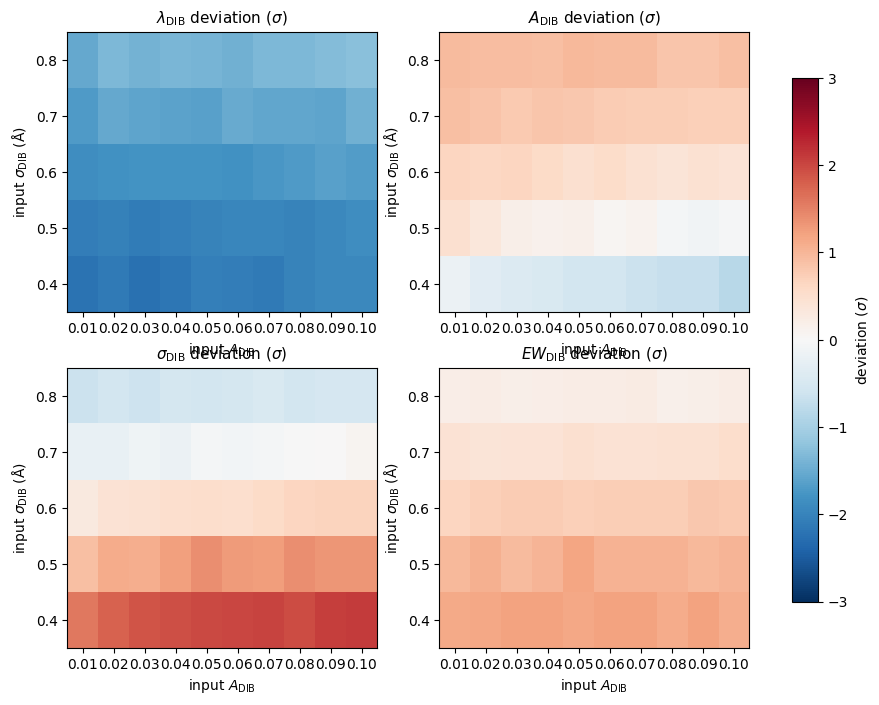

max |deviation| over the scan = 2.23 sigma (16 of 200 values exceed 2 sigma, none exceed 3 sigma)


In [3]:
import matplotlib.pyplot as plt

sig = np.array(sorted({r['sigma_true'] for r in scan}))
amp = np.array(sorted({r['A_true'] for r in scan}))
grid = lambda key: np.array([[next(r[key] for r in scan
                                  if r['sigma_true'] == s and r['A_true'] == a) for a in amp]
                             for s in sig])
# equivalent width from the fit: EW = A * sigma * sqrt(2 pi); deviation in units of its own error
def ew_dev(row):
    ew = row['A_DIB_fit'] * row['sigma_DIB_fit'] * np.sqrt(2 * np.pi)
    ew_err = ew * np.sqrt((row['A_DIB_err'] / row['A_DIB_fit']) ** 2 + (row['sigma_DIB_err'] / row['sigma_DIB_fit']) ** 2)
    ew_true = row['A_true'] * row['sigma_true'] * np.sqrt(2 * np.pi)
    return (ew - ew_true) / ew_err

panels = [('$\\lambda_{\\rm DIB}$', grid('sigma_dev_lambda')),
          ('$A_{\\rm DIB}$', grid('sigma_dev_A')),
          ('$\\sigma_{\\rm DIB}$', grid('sigma_dev_sigma')),
          ('$EW_{\\rm DIB}$', np.array([[ew_dev(next(r for r in scan if r['sigma_true'] == s and r['A_true'] == a))
                                          for a in amp] for s in sig]))]
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, (label, dev) in zip(axes.ravel(), panels):
    im = ax.imshow(dev, origin='lower', cmap='RdBu_r', vmin=-3, vmax=3, aspect='auto')
    ax.set_xticks(range(len(amp)), [f'{a:.2f}' for a in amp])
    ax.set_yticks(range(len(sig)), [f'{s:.1f}' for s in sig])
    ax.set_xlabel('input $A_{\\rm DIB}$'); ax.set_ylabel('input $\\sigma_{\\rm DIB}$ ($\\rm\\AA$)')
    ax.set_title(label + ' deviation ($\\sigma$)', fontsize=11)
fig.colorbar(im, ax=axes, shrink=0.85, label='deviation ($\\sigma$)')
fig.savefig(FIG / 'nb04_scan.png', dpi=200, bbox_inches='tight')
plt.show()

devs = np.concatenate([p[1].ravel() for p in panels])
print(f'max |deviation| over the scan = {np.nanmax(np.abs(devs)):.2f} sigma '
      f'({np.sum(np.abs(devs) > 2)} of {devs.size} values exceed 2 sigma, none exceed 3 sigma)')

The scan shows where the method is comfortable and where it is not:

* all 50 cases stay below $3\sigma$, but the deviations grow towards the **narrow** end: at
  $\sigma_{\rm DIB}=0.4\,\rm\AA$ only about three pixels sample the line, so the width and the
  centre become harder to pin down;
* the **depth** has almost no effect on the EW, but a deeper line is easier to fit;
* the narrow end is a prior-boundary effect as well: the default prior is
  $\sigma_{\rm DIB}\in[0.3,1.0]\,\rm\AA$, so lines narrower than $\sim0.35\,\rm\AA$ (e.g.
  $\lambda$6660 with $\sigma\approx0.30\,\rm\AA$) or broader than $\sim0.9\,\rm\AA$ sit at the
  edge of (or outside) the default box.

## 2. Reconfiguring the model for another DIB

In [4]:
# a lambda 6379 mock: narrower and weaker than lambda 6614, different window
d = load_mock(ROOT / 'data/mock/mock_6379.npz')
wave, flux, err = d['wave_analysis'], d['fluxs'], d['y_errs']
rvs, rv_err = d['rv_obs'], d['rv_err']
print(f'window {wave.min():.1f}-{wave.max():.1f} A | {wave.size} pixels | {flux.shape[0]} epochs')

model = SpectralModel(
    stellar_lines=[StellarLine('star', 6378.68, center_bounds=(6375.0, 6383.0))],
    dib=DIB(center=6379.60, center_bounds=(6378.5, 6381.0), sigma_bounds=(0.2, 1.0)))
print(model)
for name, (lo, hi) in zip(model.param_names, model.bounds):
    print(f'  {name:>12}: prior ({lo}, {hi})')

window 6350.0-6409.9 A | 500 pixels | 24 epochs
SpectralModel(stellar_lines=[star@6378.6800], dib=gaussian, n_params=6)
   lambda_star: prior (6375.0, 6383.0)
        A_star: prior (0.001, 0.4)
    sigma_star: prior (0.001, 1.0)
    lambda_DIB: prior (6378.5, 6381.0)
         A_DIB: prior (0.001, 0.2)
     sigma_DIB: prior (0.2, 1.0)


In [5]:
if RERUN:
    p0 = model.initial_guess(stars=[[6378.68, 0.0044, 0.54]], dib=[6379.60, 0.031, 0.384])
    res = run_mcmc(model, wave, flux, err, rvs, rv_err, p0=p0,
                   snrs=np.full(len(rvs), 200.0), seed=42)
    res.save(ROOT / 'examples/results/other_dib_6379.npz', thin=10)
else:
    res = load_result(ROOT / 'examples/results/other_dib_6379.npz')
truth = np.array([6378.68, 0.0044, 0.54, 6379.60, 0.0307, 0.384])
print(res.summary())
for name, value, true in zip(model.param_names, res.pfit, truth):
    print(f'  {name:>12}: {value:.4f} (input {true:.4f})')

       parameter          value          +/-
----------------------------------------------
     lambda_star     6378.68740      0.07342
          A_star        0.00393      0.00046
      sigma_star        0.55119      0.07927
      lambda_DIB     6379.60047      0.00762
           A_DIB        0.03154      0.00054
       sigma_DIB        0.38320      0.00825
----------------------------------------------
lnL = -6017.72 | AIC = 12047.45 | BIC = 12091.81
tau = [63.  67.7 66.9 64.1 58.2 59. ] | label = Success
walkers = 48 | burn-in = 1500 | production = 5000
   lambda_star: 6378.6874 (input 6378.6800)
        A_star: 0.0039 (input 0.0044)
    sigma_star: 0.5512 (input 0.5400)
    lambda_DIB: 6379.6005 (input 6379.6000)
         A_DIB: 0.0315 (input 0.0307)
     sigma_DIB: 0.3832 (input 0.3840)


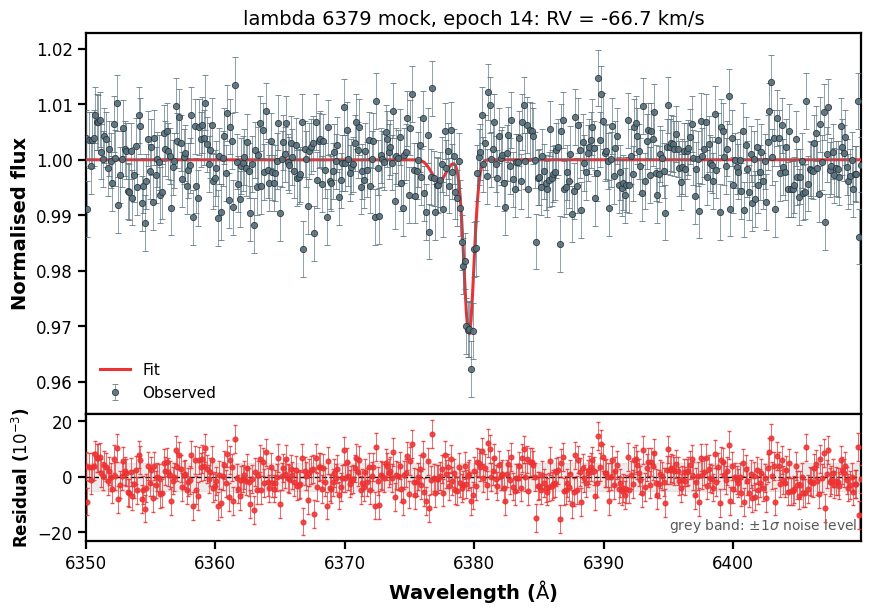

In [6]:
i = int(np.argmax(np.abs(rvs)))
plotting.plot_spectrum_fit(wave, flux, err, rvs, model, res.pfit, epoch=i,
                           title=f'lambda 6379 mock, epoch {i}: RV = {rvs[i]:+.1f} km/s',
                           out=str(FIG / 'nb04_6379_fit.png'))
plt.show()

The only changes needed for a new DIB are the window and the priors - `DIB(center=...)`,
`DIB(center_bounds=...)`, `DIB(sigma_bounds=...)` - plus the stellar line that contaminates it.
For real LAMOST MRS data, $\lambda$6379 is readily detected (it is broader), whereas the much
narrower $\lambda$6660 is difficult to measure: a narrower line means fewer sampled pixels and a
prior box that must be tuned carefully.

## What to take away

* the method is not tied to $\lambda$6614: any DIB can be fitted once the window, the
  contaminating stellar lines and the priors are configured;
* always run a small scan in width and depth before trusting the error bars of a new DIB;
* keep an eye on the prior boundaries - a fit that sits at the edge of its box is not a
  measurement.